# Week 7: TrashNet Classification using Class Weights

## Objective

The objective of this notebook is to investigate the effect of class weighting on the imbalanced TrashNet dataset. Since the Trash class contains fewer training samples than the other classes, class weights are used during training to assign a higher penalty to mistakes made on minority classes.

The same EfficientNetB0 architecture, preprocessing pipeline, and data augmentation strategy from the previous experiment are used to ensure a fair comparison.

## Workflow

- Load the TrashNet dataset
- Compute class weights using the training labels
- Train EfficientNetB0 with class weights
- Evaluate the model
- Generate the confusion matrix and classification report
- Compare the results with the previous model trained without class weights
- Analyze the effect of class weighting on minority class performance

**Dataset:** TrashNet

**Model:** EfficientNetB0 (Transfer Learning)

**Technique:** Class Weighting

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [6]:
class_names = train_dataset.class_names

train_labels_check = np.concatenate(
    [labels.numpy() for _, labels in train_dataset]
)

validation_labels_check = np.concatenate(
    [labels.numpy() for _, labels in validation_dataset]
)

print("Classes:", class_names)
print("Training images:", len(train_labels_check))
print("Validation images:", len(validation_labels_check))

print(
    "Training unique labels:",
    np.unique(train_labels_check)
)

print(
    "Validation unique labels:",
    np.unique(validation_labels_check)
)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training images: 2022
Validation images: 505
Training unique labels: [0 1 2 3 4 5]
Validation unique labels: [0 1 2 3 4 5]


In [7]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_check),
    y=train_labels_check
)

class_weight = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        np.unique(train_labels_check),
        weights
    )
}

for class_id, weight in class_weight.items():
    print(
        f"{class_names[class_id]}: {weight:.4f}"
    )

cardboard: 1.0090
glass: 0.8446
metal: 1.0466
paper: 0.7155
plastic: 0.8575
trash: 3.2718


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2)
    ],
    name="data_augmentation"
)

In [12]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("EfficientNetB0 loaded successfully.")

EfficientNetB0 loaded successfully.


In [13]:
inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.3,
    name="dropout"
)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax",
    name="predictions"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="trashnet_efficientnet_class_weights"
)

model.summary()

Model: "trashnet_efficientnet_class_weights"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [16]:
history_class_weights = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    class_weight=class_weight
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 230ms/step - accuracy: 0.5836 - loss: 1.1649 - val_accuracy: 0.8000 - val_loss: 0.6841 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.7685 - loss: 0.7057 - val_accuracy: 0.8317 - val_loss: 0.5284 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8071 - loss: 0.5829 - val_accuracy: 0.8297 - val_loss: 0.4770 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.8353 - loss: 0.5036 - val_accuracy: 0.8515 - val_loss: 0.4372 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.8417 - loss: 0.4621 - val_accuracy: 0.8515 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8472 - loss: 0.4454 - val_accuracy: 0.8554 - val_loss: 0.4136 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.8694 - loss: 0.

In [17]:
final_train_accuracy = (
    history_class_weights.history["accuracy"][-1]
)

final_validation_accuracy = (
    history_class_weights.history["val_accuracy"][-1]
)

best_validation_accuracy = max(
    history_class_weights.history["val_accuracy"]
)

print(
    f"Final Training Accuracy: "
    f"{final_train_accuracy * 100:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{final_validation_accuracy * 100:.2f}%"
)

print(
    f"Best Validation Accuracy: "
    f"{best_validation_accuracy * 100:.2f}%"
)

Final Training Accuracy: 91.20%
Final Validation Accuracy: 86.73%
Best Validation Accuracy: 87.92%


In [18]:
validation_loss, validation_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print(
    f"Restored Best Validation Loss: "
    f"{validation_loss:.4f}"
)

print(
    f"Restored Best Validation Accuracy: "
    f"{validation_accuracy * 100:.2f}%"
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.8772 - loss: 0.3486
Restored Best Validation Loss: 0.3486
Restored Best Validation Accuracy: 87.72%


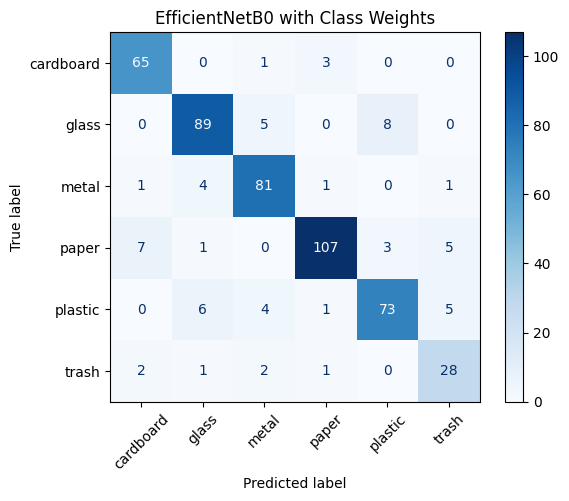

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

true_labels = []
predicted_labels = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    true_labels.extend(labels.numpy())
    predicted_labels.extend(pred_classes)

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("EfficientNetB0 with Class Weights")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=2
    )
)

              precision    recall  f1-score   support

   cardboard       0.87      0.94      0.90        69
       glass       0.88      0.87      0.88       102
       metal       0.87      0.92      0.90        88
       paper       0.95      0.87      0.91       123
     plastic       0.87      0.82      0.84        89
       trash       0.72      0.82      0.77        34

    accuracy                           0.88       505
   macro avg       0.86      0.87      0.87       505
weighted avg       0.88      0.88      0.88       505



# Conclusion

This experiment evaluated the impact of class weighting on the TrashNet dataset using the EfficientNetB0 transfer learning model.

The model achieved a restored best validation accuracy of **87.72%**, which is only slightly lower than the previous model without class weighting (**88.12%**).

The most significant improvement was observed in the **Trash** class, where recall increased from **0.74** to **0.82**. This indicates that the model became more effective at recognizing the minority class after applying class weights.

Although there was a small reduction in overall validation accuracy, the improved recall for the rare Trash class demonstrates the benefit of class weighting for imbalanced datasets. Depending on the application, this trade-off can be valuable because correctly identifying minority classes is often more important than achieving the highest possible overall accuracy.

Overall, class weighting proved to be an effective strategy for improving minority-class detection while maintaining strong overall performance.